# Comparing Homogeneity-Parsimony to other trade-off formulations

This notebook compares the homogeneity--parsimony scores to alternative ways of visualizing clustering success. It uses simple clusterings of six objects from three classes to illustrate the behavior of the scores.

In [1]:
import string
import numpy as np
import pandas as pd
import sklearn

from clustereval import *

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import pyrepseq.plotting as pp

plt.style.use('clustereval.mplstyle')
ticks = [0, 0.5, 1.0]

pd.options.display.float_format = "{:.2f}".format

## Comparison of parsimony and completeness scores

In [2]:
labels_true = [1, 1, 1, 2, 2, 2]
labels_pred_list = [[1, 1, 1, 1, 1, 1],
                    [1, 1, 1, 1, 1, 2],
                    [1, 1, 1, 2, 2, 3],
                    [1, 2, 3, 4, 5, 6],
                    ]

hkcs = []
hks = []
Is = []
homogeneities = []
parsimonies = []
completenesss = []
v_measures = []
q_measures = []
for labels_pred in labels_pred_list:  
    entropy_joint, entropy_CK, entropy_KC, entropy_C, entropy_K = conditional_entropies(labels_true, labels_pred)
    hkc = entropy_KC/np.log(2)
    hk = entropy_K/np.log(2)
    i = (entropy_K - entropy_KC)/np.log(2)
    homogeneities.append(homogeneity_score(labels_true, labels_pred))
    parsimonies.append(parsimony_score(labels_true, labels_pred))
    completenesss.append(completeness_score(labels_true, labels_pred))
    v_measures.append(sklearn.metrics.v_measure_score(labels_true, labels_pred))
    q_measures.append(q_measure_score(labels_true, labels_pred))
    hkcs.append(hkc)
    hks.append(hk)
    Is.append(i)

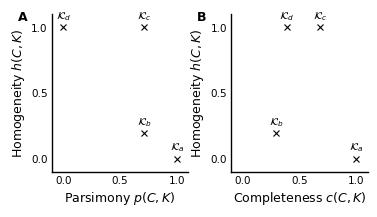

In [3]:
fig, axes = plt.subplots(figsize=(3.6, 2.0), ncols=2, sharey=False)


ax = axes[0]
for i, (x, y) in enumerate(zip(parsimonies, homogeneities)):
    cluster_label = string.ascii_lowercase[i]
    ax.plot(x, y, marker='x', linestyle='', color='k')
    ax.annotate('$\mathcal{K}_'+f'{cluster_label}$', (x, y),
                textcoords="offset points", xytext=(0,+8),
                ha='center', va='center', fontsize='small')
ax.set_xlabel('Parsimony $p(C, K)$')
ax.set_ylabel('Homogeneity $h(C, K)$')

ax = axes[1]
for i, (x, y) in enumerate(zip(completenesss, homogeneities)):
    cluster_label = string.ascii_lowercase[i]
    ax.plot(x, y, marker='x', linestyle='', color='k')
    ax.annotate('$\mathcal{K}_'+f'{cluster_label}$', (x, y),
                textcoords="offset points", xytext=(0,+8),
                ha='center', va='center', fontsize='small')
ax.set_xlabel('Completeness $c(C, K)$')
ax.set_ylabel('Homogeneity $h(C, K)$')


for ax in axes:
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

fig.tight_layout(pad=0.1)

pp.label_axes(axes, xy=(-0.25, 1.02))
fig.savefig('completeness_parsimony_example.svg')

Clusterings $\mathcal{K}_c$ and $\mathcal{K}_d$ are refinements of clustering $\mathcal{K}_b$ and have higher homogeneity and equal or lower parsimony, respectively. In contrast, the completeness score of the maximally fragmented clustering $\mathcal{K}_d$ is non-zero, and the completeness of clusterings $\mathcal{K}_c$ and $\mathcal{K}_d$ exceeds the value assigned to the substantially simpler clustering $\mathcal{K}_b$. The assignment of a non-zero completeness score to maximally fragmented clusterings is a general phenomenon: completeness is a cluster entropy normalized mutual information, $c(C, K) = I(C, K)/H(    K)$, where for the fully fragmented clustering $\tilde K$, $I(C, \tilde K)=H(C)$ and $H(\tilde K)=\log N$. Hence $c(C,\tilde K) = H(C)/\log N$. Intuitively, as the normalization by $H(K)$ increases for fragmented clusterings, the completeness score can be overly favorable to fragmented clusterings. This problem is fixed by our definition of the parsimony score, which uses a fixed normalization independent of the clustering complexity to avoid overclustering.

In [4]:
df = pd.DataFrame({
        'Clustering': ['$\mathcal{K}_a$', '$\mathcal{K}_b$', '$\mathcal{K}_c$', '$\mathcal{K}_d$', '$\mathcal{C}$'],
        'Clusters': labels_pred_list+[labels_true],
        'Q-Measure': q_measures + [np.nan],
        'V-Measure': v_measures + [np.nan],
    })
df

,Clustering,Clusters,Q-Measure,V-Measure
0,$\mathcal{K}_a$,"[1, 1, 1, 1, 1, 1]",0.00,0.00
1,$\mathcal{K}_b$,"[1, 1, 1, 1, 1, 2]",0.30,0.23
2,$\mathcal{K}_c$,"[1, 1, 1, 2, 2, 3]",0.83,0.81
3,$\mathcal{K}_d$,"[1, 2, 3, 4, 5, 6]",0.00,0.56
4,$\mathcal{C}$,"[1, 1, 1, 2, 2, 2]",NaN,NaN


The table above shows how Q-measure and V-Measure rank the clusterings at $\beta=1$. Both scores agree on ranking clustering $\mathcal{K}_c$ best, while clustering $\mathcal{K}_a$, which puts all objects into a single cluster, is ranked worst. However, the scores differ in their ranking of clusterings $\mathcal{K}_d$ and $\mathcal{K}_b$. V-measure ranks clustering $\mathcal{K}_d$, which puts each point in its own cluster, over clustering $\mathcal{K}_b$. Q-measure ranks $\mathcal{K}_b$ higher and assigns a score of zero to $\mathcal{K}_d$. This better reflects intuition, as clustering $\mathcal{K}_d$ is the least parsimonious. Q-measure can thus serve as an alternative to V-measure, which more strongly penalizes overclustering.

## Comparison to evaluation on the Information Bottleneck plane

In [5]:
labels_true = [1, 1, 2, 2, 3, 3]
labels_pred_list = [[1, 1, 1, 1, 1, 1],
                    [1, 1, 1, 2, 2, 2],
                    [1, 1, 2, 2, 3, 3],
                    [1, 2, 3, 4, 5, 6]]

hkcs = []
Is = []
homogeneities = []
parsimonies = []
completenesss = []
v_measures = []
q_measures = []
for labels_pred in labels_pred_list:  
    entropy_joint, entropy_CK, entropy_KC, entropy_C, entropy_K = conditional_entropies(labels_true, labels_pred)
    hkc = entropy_KC/np.log(2)
    hk = entropy_K/np.log(2)
    i = (entropy_K - entropy_KC)/np.log(2)
    homogeneities.append(homogeneity_score(labels_true, labels_pred))
    parsimonies.append(parsimony_score(labels_true, labels_pred))
    completenesss.append(completeness_score(labels_true, labels_pred))
    v_measures.append(sklearn.metrics.v_measure_score(labels_true, labels_pred))
    q_measures.append(q_measure_score(labels_true, labels_pred))
    hkcs.append(hkc)
    hks.append(hk)
    Is.append(i)

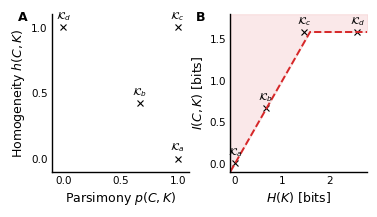

In [6]:
fig, axes = plt.subplots(figsize=(3.6, 2.0), ncols=2, sharey=False)

ax = axes[0]
for i, (x, y) in enumerate(zip(parsimonies, homogeneities)):
    cluster_label = string.ascii_lowercase[i]
    ax.plot(x, y, marker='x', linestyle='', color='k')
    ax.annotate('$\mathcal{K}_'+f'{cluster_label}$', (x, y),
                textcoords="offset points", xytext=(0,+8),
                ha='center', va='center', fontsize='small')

ax.set_xlabel('Parsimony $p(C, K)$')
ax.set_ylabel('Homogeneity $h(C, K)$')
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(-0.1, 1.1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)


ax = axes[1]
for i, (x, y) in enumerate(zip(hks, Is)):
    cluster_label = string.ascii_lowercase[i]
    ax.plot(x, y, marker='x', linestyle='', color='k')
    ax.annotate('$\mathcal{K}_'+f'{cluster_label}$', (x, y),
                textcoords="offset points", xytext=(0,+8),
                ha='center', va='center', fontsize='small')
ax.set_xlabel('$H(K)$ [bits]')
ax.set_ylabel('$I(C, K)$ [bits]')
ax.set_ylim(-0.1, 1.8)
ax.set_xlim(-0.1, 2.8)
ax.set_yticks([0, 0.5, 1.0, 1.5])

hc = np.log2(3)
ax.plot([-0.1, hc, 2.8], [-0.1, hc, hc],
        color='C3', linestyle='--')
ax.fill_between([-0.1, hc, 2.8], [-0.1, hc, hc], [1.8, 1.8, 1.8],
                color='C3', alpha=0.1)

fig.tight_layout(pad=0.1)

pp.label_axes(axes, xy=(-0.25, 1.02))
fig.savefig('parsimony_compression_example.svg')

 Clusterings $\mathcal{K}_a$, $\mathcal{K}_b$ have lower relevance than $\mathcal{K}_c$, but also lower $H(K)$. In the deterministic IB plane, $\mathcal{K}_a$ and $\mathcal{K}_b$ would therefore appear Pareto-optimal when considering relevance and $H(K)$ as the two competing objectives. In the homogeneity--parsimony plane only clustering $\mathcal{K}_c$ is Pareto-optimal, and it is precisely the clustering that perfectly aligns with the classes. In external validation on a finite dataset this is the desired behavior: once a clustering matches the resolution determined by the ground truth (clustering $\mathcal{K}_c$), additional lossy compression should no longer be rewarded. Replacing $H(K)$ by $H(K\mid C)$ achieves this.

In [7]:
df = pd.DataFrame({
        'Clustering': ['$\mathcal{K}_a$', '$\mathcal{K}_b$', '$\mathcal{K}_c$', '$\mathcal{K}_d$', '$\mathcal{C}$'],
        'Clusters': labels_pred_list+[labels_true],
        'Q-Measure': q_measures + [np.nan],
        'V-Measure': v_measures + [np.nan],
    })
df

,Clustering,Clusters,Q-Measure,V-Measure
0,$\mathcal{K}_a$,"[1, 1, 1, 1, 1, 1]",0.00,0.00
1,$\mathcal{K}_b$,"[1, 1, 1, 2, 2, 2]",0.52,0.52
2,$\mathcal{K}_c$,"[1, 1, 2, 2, 3, 3]",1.00,1.00
3,$\mathcal{K}_d$,"[1, 2, 3, 4, 5, 6]",0.00,0.76
4,$\mathcal{C}$,"[1, 1, 2, 2, 3, 3]",NaN,NaN


The table again shows how Q-measure and V-Measure rank the clusterings at $\beta=1$. The fully fragmented clustering $\mathcal{K}_d$ is again ranked second-best by V-measure, while being assigned a score of zero by Q-measure.